In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix
import os

In [ ]:
base_dir = r"C:\Users\cambo\Desktop\Subglacial_Lakes_Data"
checkpoint_path = b'asymmetric_focal_model.pth' # Best model using the asymmetric focal loss function
createNew = False # Set to True to create new checkpoint file, False to load existing one

In [2]:
# ============================================
# DICE LOSS CLASS (for combined loss)
# ============================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        union = probs.sum() + targets.sum()
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

# ============================================
# FOCAL LOSS (goal is to reduce false positives by focusing on hard examples)
# ============================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        
        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_weight = alpha_t * focal_weight
        
        loss = focal_weight * ce_loss
        return loss.mean()

# ============================================
# ASYMMETRIC FOCAL LOSS (for extreme imbalance)
# ============================================
class AsymmetricFocalLoss(nn.Module):
    """
    Asymmetric Focal Loss: applies different gamma for positives vs negatives.
    γ_pos = 0 means: never down-weight positive (lake) examples
    γ_neg > 0 means: down-weight easy negatives (background)
    
    This prevents the model from ignoring rare lake pixels.
    """
    def __init__(self, gamma_pos=0, gamma_neg=1.5, alpha=0.6, eps=1e-6):
        """
        Args:
            gamma_pos: gamma for positive class (lake) — 0 means no down-weighting
            gamma_neg: gamma for negative class (background) — higher = more down-weighting
            alpha: class balance weight (higher = more focus on lakes)
        """
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.alpha = alpha
        self.eps = eps
        
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        
        # Standard BCE loss (per pixel)
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # p_t = probability of true class
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Apply different gamma based on class
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        focal_weight = (1 - p_t + self.eps) ** gamma
        
        # Class balancing (alpha)
        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_weight = focal_weight * alpha_t
        
        loss = focal_weight * ce_loss
        return loss.mean()
    
# ============================================
# AUGMENTATION FUNCTION (rotate, flip, noise, brightness, crop to get rid of center bias)
# ============================================

def random_crop(img, mask, crop_size=448):
    """
    Randomly crop image and mask to the same location
    img: [C, H, W] tensor
    mask: [1, H, W] tensor
    """
    _, h, w = img.shape
    crop_size = min(crop_size, h, w)
    
    y = random.randint(0, h - crop_size)
    x = random.randint(0, w - crop_size)
    
    img_cropped = img[:, y:y+crop_size, x:x+crop_size]
    mask_cropped = mask[:, y:y+crop_size, x:x+crop_size]
    
    return img_cropped, mask_cropped

def augment_batch(X, y):
    """ 
    Applies diverse augmentations to a batch of images and masks.
    """
    # ===== RANDOM CROP FIRST (before other transforms) =====
    if random.random() > 0.5:  # 50% chance to crop
        cropped_X = []
        cropped_y = []
        for i in range(X.shape[0]):
            img_crop, mask_crop = random_crop(X[i], y[i], crop_size=448)
            cropped_X.append(img_crop)
            cropped_y.append(mask_crop)
        X = torch.stack(cropped_X)
        y = torch.stack(cropped_y)
    # ======================================================

    # --- Spatial Transforms ---
    if random.random() > 0.5:
        X = torch.flip(X, dims=[3])
        y = torch.flip(y, dims=[3])

    if random.random() > 0.5:
        X = torch.flip(X, dims=[2])
        y = torch.flip(y, dims=[2])

    if random.random() > 0.5:
        k = random.randint(1, 3)
        X = torch.rot90(X, k, dims=[2, 3])
        y = torch.rot90(y, k, dims=[2, 3])

    return X, y

# ============================================
# BALANCED BATCH SAMPLER (fixes forgetting)
# ============================================
class BalancedBatchSampler(Sampler):
    """
    Sampler that ensures batches have a fixed ratio of lake vs null images.
    Yields ONE index at a time - DataLoader handles batching.
    """
    def __init__(self, lake_indices, null_indices, batch_size, lake_ratio=0.5):
        self.lake_indices = lake_indices
        self.null_indices = null_indices
        self.batch_size = batch_size
        self.lake_ratio = lake_ratio

        self.lake_per_batch = int(batch_size * lake_ratio)
        self.null_per_batch = batch_size - self.lake_per_batch

        assert self.lake_per_batch > 0, "Lake ratio too low, no lakes in batch."
        assert self.null_per_batch > 0, "Lake ratio too high, no null in batch."
        
        # Calculate total batches per epoch
        self.num_batches = min(len(lake_indices) // self.lake_per_batch,
                               len(null_indices) // self.null_per_batch)

    def __iter__(self):
        # Create infinite cycling iterators
        lake_cycle = self._cycle(self.lake_indices)
        null_cycle = self._cycle(self.null_indices)

        # Yield exactly ONE epoch worth of indices
        for _ in range(self.num_batches * self.batch_size):
            # Alternate between lake and null to maintain ratio
            if (_ % self.batch_size) < self.lake_per_batch:
                yield next(lake_cycle)
            else:
                yield next(null_cycle)

    def _cycle(self, indices):
        """Cycles through shuffled indices infinitely."""
        while True:
            shuffled = indices.copy()
            random.shuffle(shuffled)
            for idx in shuffled:
                yield idx

    def __len__(self):
        # Return total number of indices per epoch
        return self.num_batches * self.batch_size

# ============================================
# METRICS FUNCTIONS (Dice, IoU, confusion matrix)
# ============================================
def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    total = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    union = total - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

@torch.no_grad()
def quick_check(model, loader, device):
    """Quick confusion matrix check"""
    model.eval()
    all_preds = []
    all_targets = []
    
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(y.cpu().numpy().flatten())
    
    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"TN: {tn}, FP: {fp}")
    print(f"FN: {fn}, TP: {tp}")
    print(f"False positive rate: {fp/(fp+tn):.4f}")

# ============================================
# EVALUATION FUNCTION
# ============================================
@torch.no_grad()
def evaluate_segmentation(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        
        # Debug prints (optional)
        probs = torch.sigmoid(logits)
        print(f"Batch {n_batches}:")
        print(f"  Probability range: {probs.min():.4f} - {probs.max():.4f}")
        print(f"  Mean probability: {probs.mean():.4f}")
        print(f"  Predictions >0.1: {(probs > 0.1).float().mean():.4f}")
        print(f"  Predictions >0.5: {(probs > 0.5).float().mean():.4f}")
        
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_dice += dice_score_from_logits(logits, y)
        total_iou += iou_score_from_logits(logits, y)
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "dice": total_dice / n_batches,
        "iou": total_iou / n_batches,
    }

# ============================================
# FUNCTION TO CREATE BALANCED LOADER
# ============================================
def create_balanced_loader(train_dataset, batch_size=4, lake_ratio=0.5):
    """Scan dataset and create balanced loader with lake/null ratio"""
    lake_indices = []
    null_indices = []
    
    for i in range(len(train_dataset)):
        _, mask = train_dataset[i]
        if (mask == 1).any():
            lake_indices.append(i)
        else:
            null_indices.append(i)
    
    # Create sampler
    balanced_sampler = BalancedBatchSampler(
        lake_indices, null_indices, batch_size, lake_ratio
    )
    
    # Create loader with sampler (NO shuffle=True)
    balanced_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=balanced_sampler,  # sampler replaces shuffle
        num_workers=0,
        pin_memory=False,
        drop_last=True  # This ensures all batches are full size
    )
    
    return balanced_loader, lake_indices, null_indices
    


In [ ]:
# ============================================
# IMPORT DATA AND CREATE DATAFRAMES
# ============================================

#set paths 
lake_location_path = os.path.join(base_dir, "lake_locations.csv")
lake_and_null_path = os.path.join(base_dir, "lake_and_null_loc.csv")
dataset_split_path = os.path.join(base_dir, "dataset_split.csv")
lake_masks = os.path.join(base_dir, "lake_masks")
training_set = os.path.join(base_dir, "lakesTS_2")

# import data
lake_location = pd.read_csv(lake_location_path)
lake_and_null = pd.read_csv(lake_and_null_path)
dataset_split = pd.read_csv(dataset_split_path)

# list all netcdf files in each folder
tile_files = sorted([f for f in os.listdir(training_set) if f.endswith(".nc")])
mask_files = sorted([f for f in os.listdir(lake_masks) if f.endswith(".nc")])

print("number of training files:", len(tile_files))
print("number of lake mask files:", len(mask_files))
# we expect a difference because there are some null training files - i.e., where there are not lakes = no lake masks

# create a dataframe to hold the corresponding tile paths, mask paths, and labels (has lake or not)
rows = []

for tile in tile_files:
    
    name = tile.replace(".nc", "")
    
    tile_path = os.path.join(training_set, tile)
    
    mask_file = f"{name}_mask.nc"
    mask_path = os.path.join(lake_masks, mask_file)
    
    if os.path.exists(mask_path):
        has_mask = True
    else:
        mask_path = None
        has_mask = False
    
    rows.append({
        "name": name,
        "tile_path": tile_path,
        "mask_path": mask_path,
        "has_lake": int(has_mask)
    })

dataset_df = pd.DataFrame(rows)

# import class information (train, val, test) based on dataset_split.csv
dataset_split["file_name"] = (
    dataset_split["file"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .str.split("/")
    .str[-1]
)

# isolate the name of the lake from the file path
dataset_split["name"] = dataset_split["file_name"].str.replace(".nc", "", regex=False)

# merge split with dataset dataframe
dataset_df = dataset_df.merge(
    dataset_split[["name", "dataset"]],
    on="name",
    how="left"
)

# break dataset into 3 categories
train_df = dataset_df[dataset_df["dataset"] == "train"].reset_index(drop=True)
val_df = dataset_df[dataset_df["dataset"] == "val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["dataset"] == "test"].reset_index(drop=True)

# After creating train_df, reset the index AGAIN to be safe:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ============================================
# PATCH-BASED DATASET CLASS (LOADS FULL IMAGE, EXTRACTS PATCHES ON THE FLY, APPLIES AUGMENTATION)
# ============================================
class PatchLakeDataset(Dataset):
    def __init__(self, dataframe, tile_var="anomaly", mask_var="lake_mask", 
                 patch_size=256, stride=128, augment=True):
        """
        Patch-based dataset for lake segmentation.
        
        Args:
            dataframe: DataFrame with tile_path and mask_path
            tile_var: variable name in netCDF for anomaly data
            mask_var: variable name in netCDF for mask
            patch_size: size of square patches (e.g., 256)
            stride: stride for patch extraction (smaller = more patches)
            augment: whether to apply augmentation
        """
        self.df = dataframe.reset_index(drop=True)
        self.tile_var = tile_var
        self.mask_var = mask_var
        self.patch_size = patch_size
        self.stride = stride
        self.augment = augment
        
        # Pre-compute all patches
        self.patches = []
        print("Generating patches...")
        
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            
            # Load and process image once per file
            X, _ = self._load_image_mask(row, return_mask=False)
            h, w = X.shape[1], X.shape[2]
            
            # Extract patches
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    self.patches.append({
                        'idx': idx,
                        'y': y,
                        'x': x,
                        'has_lake': None  # Will check when loading
                    })
        
        print(f"Created {len(self.patches)} patches from {len(self.df)} images")
    
    def _load_image_mask(self, row, return_mask=True):
        """Load and process full image and mask"""
        # Load tile
        tile_path = str(row["tile_path"])
        tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
        arr = tile_ds[self.tile_var].values.astype(np.float32)
        tile_ds.close()
        
        # Process to 2-channel (mean, std)
        valid = np.isfinite(arr)
        valid_count = valid.sum(axis=0)
        
        arr_zeroed = np.where(valid, arr, 0.0)
        mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
        
        diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
        std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
        
        mean_img[valid_count == 0] = 0.0
        std_img[valid_count == 0] = 0.0
        
        x = np.stack([mean_img, std_img], axis=0)
        
        # Normalize
        GLOBAL_MEAN_MEAN = -2.4824232087901197 
        GLOBAL_STD_MEAN = 20.268677019954087   
        GLOBAL_STD_STD = 3.7701363263330427   
        
        x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
        x[1] = x[1] / GLOBAL_STD_STD
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        
        if not return_mask:
            return torch.tensor(x, dtype=torch.float32), None
        
        # Load mask
        if pd.isna(row["mask_path"]) or row["mask_path"] is None:
            mask = np.zeros((x.shape[1], x.shape[2]), dtype=np.float32)
        else:
            mask_path = str(row["mask_path"])
            mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
            mask = mask_ds[self.mask_var].values.astype(np.float32)
            mask_ds.close()
        
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)
        
        return torch.tensor(x, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
    
    def __len__(self):
        return len(self.patches)
    
    def __getitem__(self, idx):
        patch_info = self.patches[idx]
        
        # Load full image and mask
        X, mask = self._load_image_mask(self.df.iloc[patch_info['idx']])
        
        # Extract patch
        y, x = patch_info['y'], patch_info['x']
        ps = self.patch_size
        
        X_patch = X[:, y:y+ps, x:x+ps]
        mask_patch = mask[:, y:y+ps, x:x+ps]
        
        # Augmentation
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                X_patch = torch.flip(X_patch, dims=[2])
                mask_patch = torch.flip(mask_patch, dims=[2])
            
            # Random vertical flip
            if random.random() > 0.5:
                X_patch = torch.flip(X_patch, dims=[1])
                mask_patch = torch.flip(mask_patch, dims=[1])
            
            # Random 90-degree rotation
            if random.random() > 0.5:
                k = random.randint(1, 3)
                X_patch = torch.rot90(X_patch, k, dims=[1, 2])
                mask_patch = torch.rot90(mask_patch, k, dims=[1, 2])
        
        return X_patch, mask_patch
    
# ============================================
# CREATE PATCH DATASETS 
# ============================================
patch_size = 256
stride = 128  # Overlap between patches

train_dataset = PatchLakeDataset(
    train_df, 
    patch_size=patch_size, 
    stride=stride,
    augment=True
)

val_dataset = PatchLakeDataset(
    val_df, 
    patch_size=patch_size, 
    stride=stride,
    augment=False  # No augmentation for validation
)

test_dataset = PatchLakeDataset(
    test_df, 
    patch_size=patch_size, 
    stride=stride,
    augment=False
)

print(f"Training patches: {len(train_dataset)}")
print(f"Validation patches: {len(val_dataset)}")
print(f"Test patches: {len(test_dataset)}")

# break training data into inputs & outputs (mask)
X, y = train_dataset[0]


# ============================================
# CREATE DATALOADERS 
# ============================================
train_loader = DataLoader(
    train_dataset, 
    batch_size=16,  # Larger batches with patches
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Test a batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: {X_batch.shape}")  # Should be [16, 2, 256, 256]

number of training files: 105
number of lake mask files: 85
Generating patches...
Created 292 patches from 73 images
Generating patches...
Created 64 patches from 16 images
Generating patches...
Created 64 patches from 16 images
Training patches: 292
Validation patches: 64
Test patches: 64
Batch shape: torch.Size([16, 2, 256, 256])


In [4]:
# ============================================
# IMAGE CONVOLUTION MODEL
# ============================================
class UNet(nn.Module):

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),  # smooths training
            nn.ReLU(),
            nn.Dropout2d(0.2),   # reduces volitility
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),  # smooths training
            nn.ReLU(),
            nn.Dropout2d(0.2)   # reduces volitility
        )

        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def _match_size(self, src, target):
        """
        Resize src spatial dims to match target spatial dims.
        src: tensor to resize
        target: tensor whose H,W we want
        """
        if src.shape[-2:] != target.shape[-2:]:
            src = F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        e1 = self.enc1(x)                  # [B, 64, 256, 256]
        e2 = self.enc2(self.pool1(e1))     # [B, 128, 128, 128]
        e3 = self.enc3(self.pool2(e2))     # [B, 256, 64, 64]

        b = self.bottleneck(self.pool3(e3))  # [B, 512, 32, 32] 

        d3 = self.up3(b)                   # may be [B, 256, 64, 64]
        d3 = self._match_size(d3, e3)      # force to [B, 256, 64, 64]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = self._match_size(out, x)   # just to be safe, ensure output matches input size
        return out
    
# ============================================
# MODEL WEIGHTS & TRAINING
# ============================================
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

for X, y in train_loader:
    print(f"Batch size: {X.shape[0]}")
    break

def train_one_epoch(model, loader, criterion, optimizer, device, alpha=0.7, bce=None, dice_loss=None):
    """
    Train for one epoch using combined BCE + Dice loss
    """
    model.train()
    total_loss = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        
        # ===== APPLY AUGMENTATIONS =====
        X, y = augment_batch(X, y)

        optimizer.zero_grad()
        logits = model(X)
        
        # Combined loss (BCE + Dice)
        loss = alpha * bce(logits, y) + (1-alpha) * dice_loss(logits, y)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

Batch size: 16


Batch 0:
  Probability range: 0.0047 - 0.9885
  Mean probability: 0.5138
  Predictions >0.1: 0.9991
  Predictions >0.5: 0.7276
Batch 1:
  Probability range: 0.0051 - 0.9883
  Mean probability: 0.5117
  Predictions >0.1: 0.9999
  Predictions >0.5: 0.6928
Batch 2:
  Probability range: 0.1280 - 0.9348
  Mean probability: 0.5062
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.6030
Batch 3:
  Probability range: 0.4541 - 0.6218
  Mean probability: 0.5184
  Predictions >0.1: 1.0000
  Predictions >0.5: 0.7637
Epoch 1/50 | Train Loss: 0.3664 | Val Loss: 0.1201 | Val Dice: 0.1144
*** New best model saved! Dice: 0.1144 ***
Batch 0:
  Probability range: 0.0000 - 1.0000
  Mean probability: 0.4324
  Predictions >0.1: 0.9974
  Predictions >0.5: 0.1515
Batch 1:
  Probability range: 0.0000 - 1.0000
  Mean probability: 0.4133
  Predictions >0.1: 0.9992
  Predictions >0.5: 0.0820
Batch 2:
  Probability range: 0.0068 - 0.9802
  Mean probability: 0.3972
  Predictions >0.1: 0.9999
  Predictions >0.5: 0.032

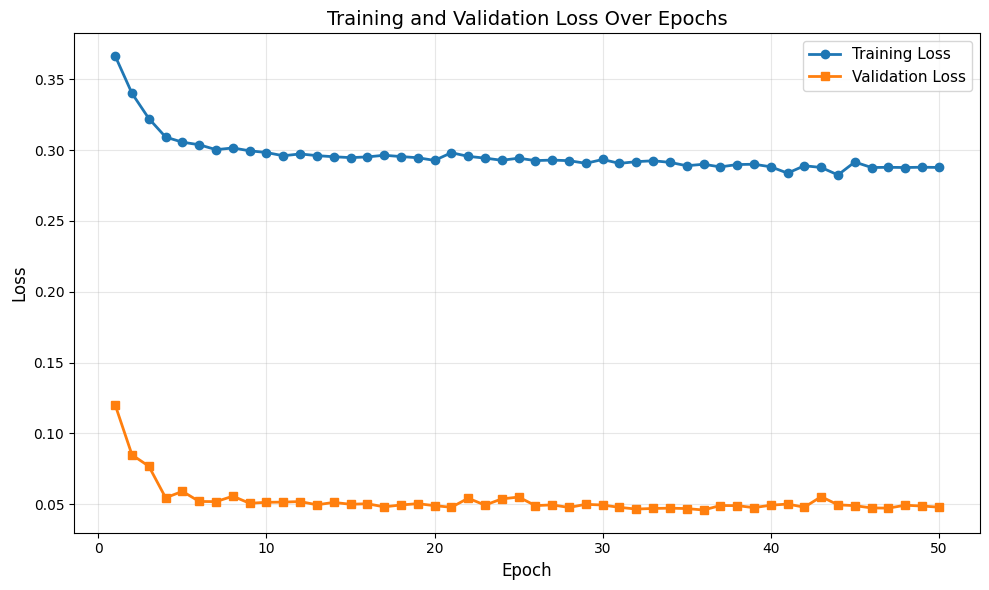

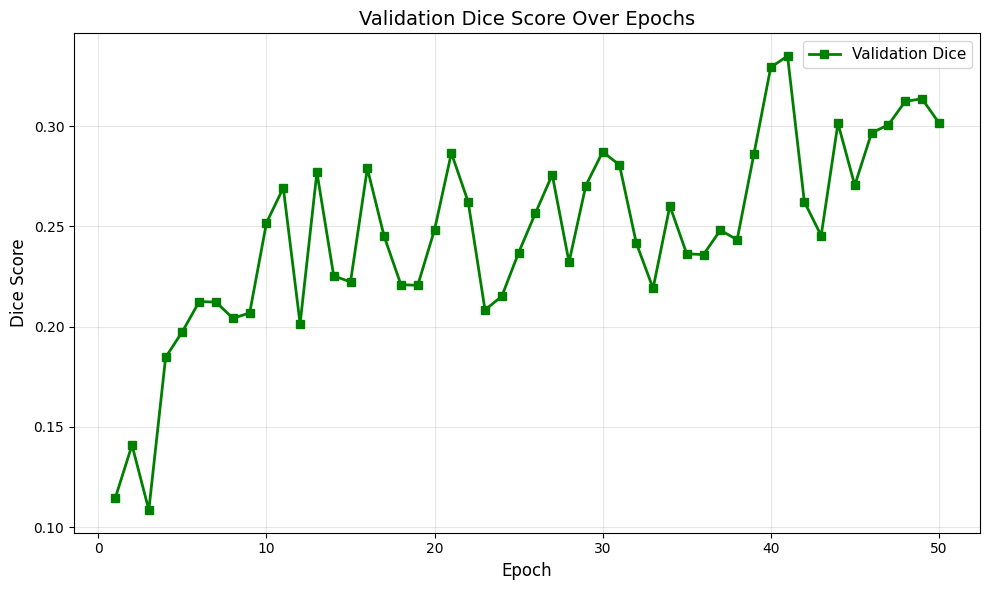


Best Dice achieved: 0.3350


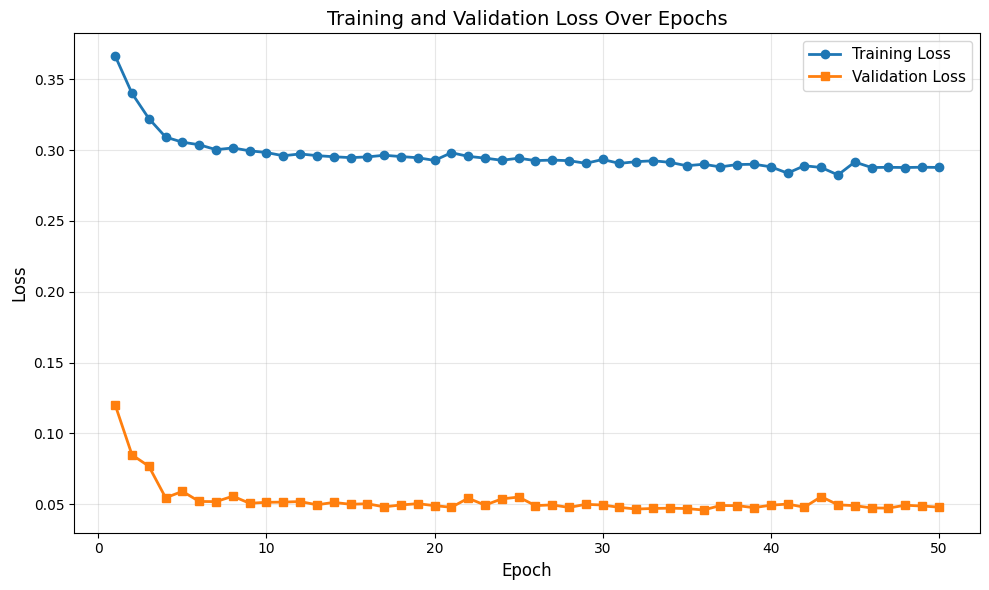

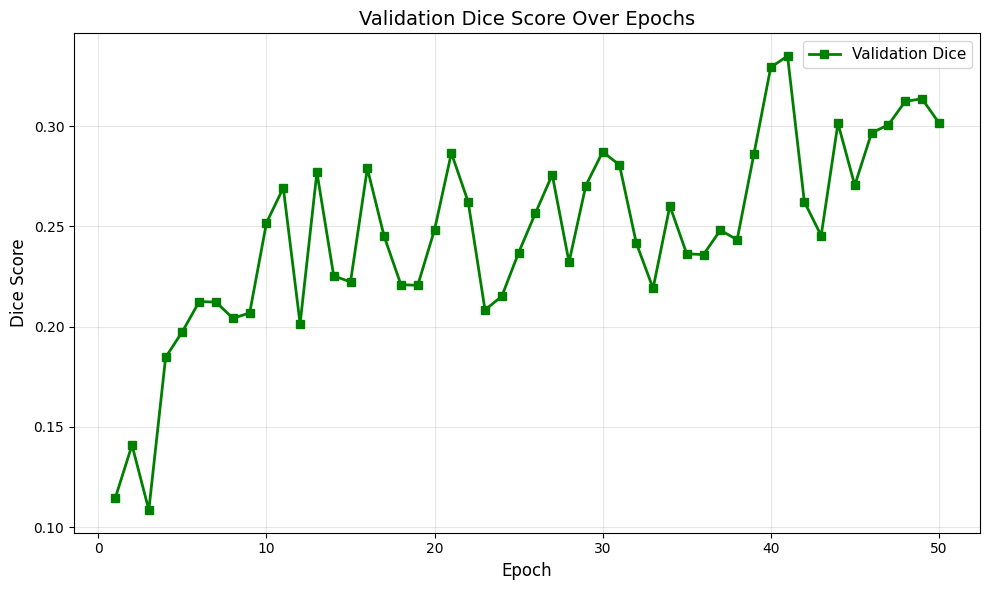


Best Dice achieved: 0.3350


In [ ]:
# ============================================
# BLOCK 4: TRAINING LOOP (Asymmetric Focal Loss)
# ============================================

if createNew == True:
    # Initialize tracking lists
    train_losses = []      # Track training loss (combined Focal + Dice)
    val_losses = []         # Track validation loss (Focal only)
    val_dice_scores = []    # Track validation Dice score (at threshold=0.5)
    best_dice = 0          # Track best Dice for model checkpointing
    num_epochs = 50        # Total training epochs

    # Device and model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(in_channels=2, out_channels=1).to(device)
    model.apply(init_weights)

    # ===== ASYMMETRIC FOCAL LOSS =====
    asymmetric_focal = AsymmetricFocalLoss(
        gamma_pos=0,      # Never down-weight lake pixels
        gamma_neg=1.5,    # Down-weight easy background
        alpha=0.6         # Extra focus on lakes (60% weight)
    )

    # Keep BCE for validation comparison (optional)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0]).to(device))

    # Dice loss for shape refinement
    dice_loss = DiceLoss()
    alpha_weight = 0.7  # 0.7 Focal + 0.3 Dice

    # Optimizer with weight decay
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)

    # Learning rate scheduler - reduces LR when Dice plateaus
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='max',        # Monitor Dice (want it to go up)
        factor=0.5,        # Reduce LR by 50% when plateau detected
        patience=5         # Wait 5 epochs before reducing
    )

    for epoch in range(num_epochs):
        # ===== TRAINING PHASE =====
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
        
            # Apply augmentations (spatial only—no noise/brightness)
            X, y = augment_batch(X, y)
        
            optimizer.zero_grad()
            logits = model(X)  # Forward pass
        
            # Combined loss: Asymmetric Focal + Dice
            loss = alpha_weight * asymmetric_focal(logits, y) + (1-alpha_weight) * dice_loss(logits, y)
        
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights
            total_loss += loss.item() * X.size(0)
    
        train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
    
        # ===== VALIDATION PHASE =====
        # Validation uses the same asymmetric focal loss for consistency
        val_results = evaluate_segmentation(model, val_loader, asymmetric_focal, device)
        val_losses.append(val_results['loss'])
        val_dice_scores.append(val_results['dice'])
    
        # Print progress
        print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_results['loss']:.4f} | "
          f"Val Dice: {val_results['dice']:.4f}")
    
        # Save best model based on validation Dice
        if val_results['dice'] > best_dice:
            best_dice = val_results['dice']
            torch.save(model.state_dict(), f'best_asymmetric_focal_epoch{epoch+1}_dice{best_dice:.3f}.pth')
            print(f"*** New best model saved! Dice: {best_dice:.4f} ***")
    
        # ===== CONFUSION MATRIX EVERY 10 EPOCHS =====
        if (epoch + 1) % 10 == 0:
            print(f"\n{'='*60}")
            print(f"CONFUSION MATRIX AT EPOCH {epoch+1}")
            print(f"{'='*60}")
            quick_check(model, val_loader, device)
            print(f"{'='*60}\n")
    
        # Adjust learning rate if Dice plateaus
        scheduler.step(val_results['dice'])

    # ============================================
    # POST-TRAINING PLOTS
    # ============================================

    # Plot training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss', linewidth=2, marker='o')
    plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', linewidth=2, marker='s')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training and Validation Loss Over Epochs', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot Dice scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), val_dice_scores, label='Validation Dice', linewidth=2, marker='s', color='green')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Dice Score', fontsize=12)
    plt.title('Validation Dice Score Over Epochs', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nBest Dice achieved: {best_dice:.4f}")

else:
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Recreate the model architecture (must match the saved model)
    model = UNet(in_channels=2, out_channels=1).to(device)
    # Load the saved weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    



RECONSTRUCTING FULL VALIDATION IMAGES
Found 14 lake images, 2 null images
Adding null image: null_4

--- Processing: null_4 ---
  Reconstructing 500x501 image with 3x3 patches...


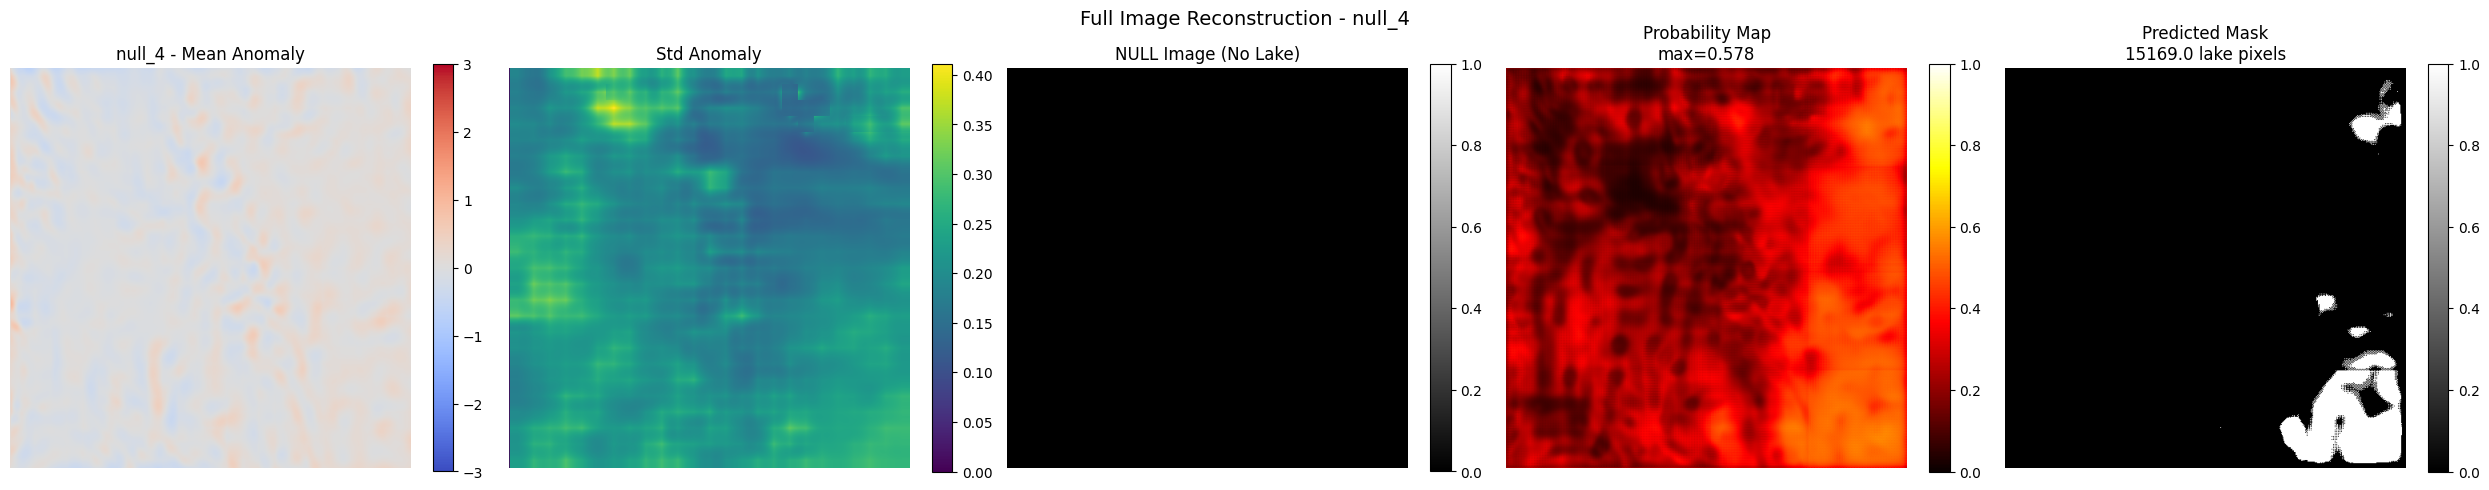

  Null image - checking for false positives...
FALSE POSITIVE: Predicted 15169.0 lake pixels in null image

--- Processing: Borchgrevink198 ---
  Reconstructing 501x501 image with 3x3 patches...


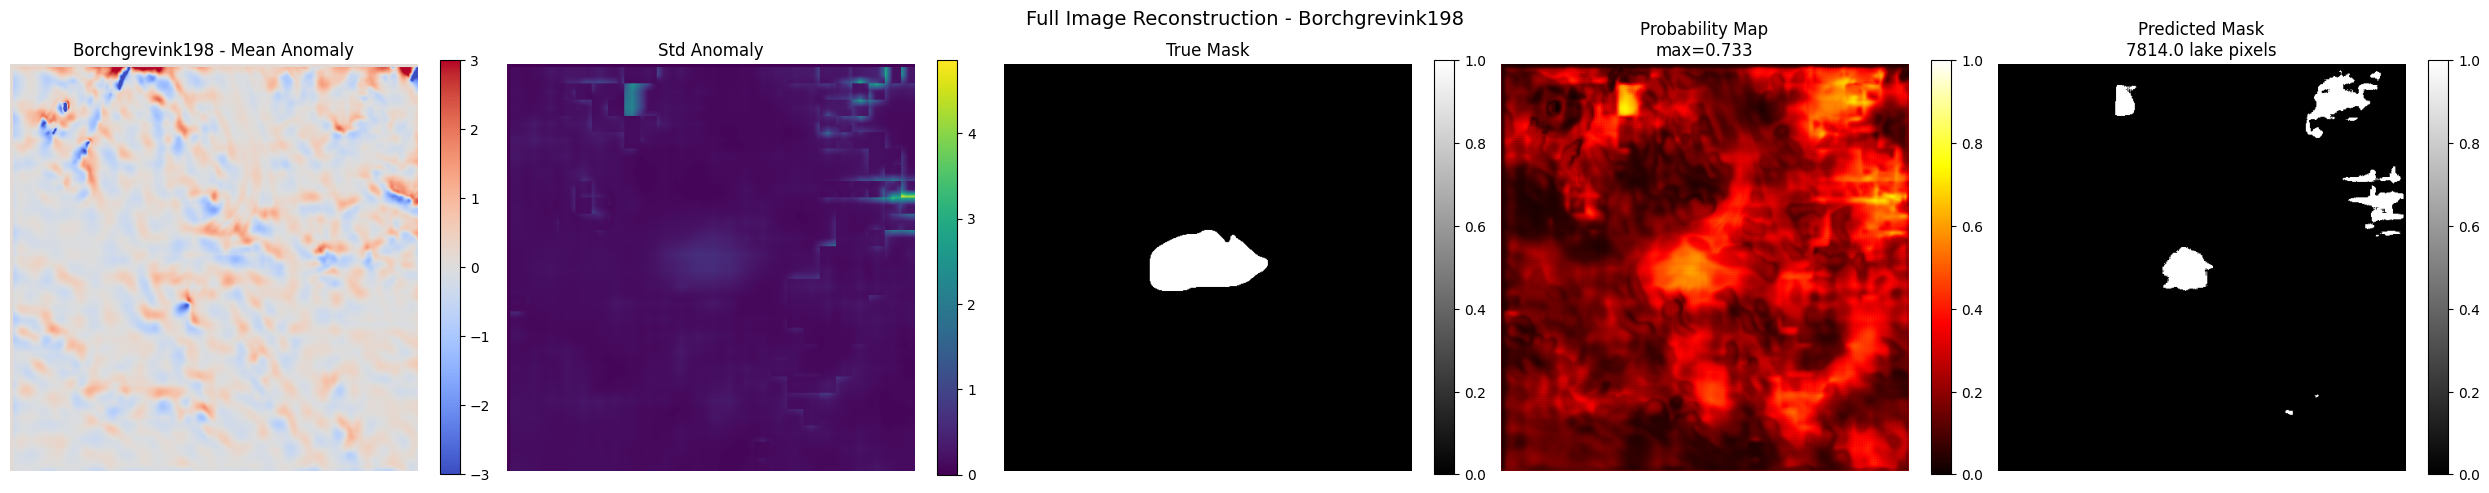

  Dice Score: 0.2825

--- Processing: Byrd10 ---
  Reconstructing 501x501 image with 3x3 patches...


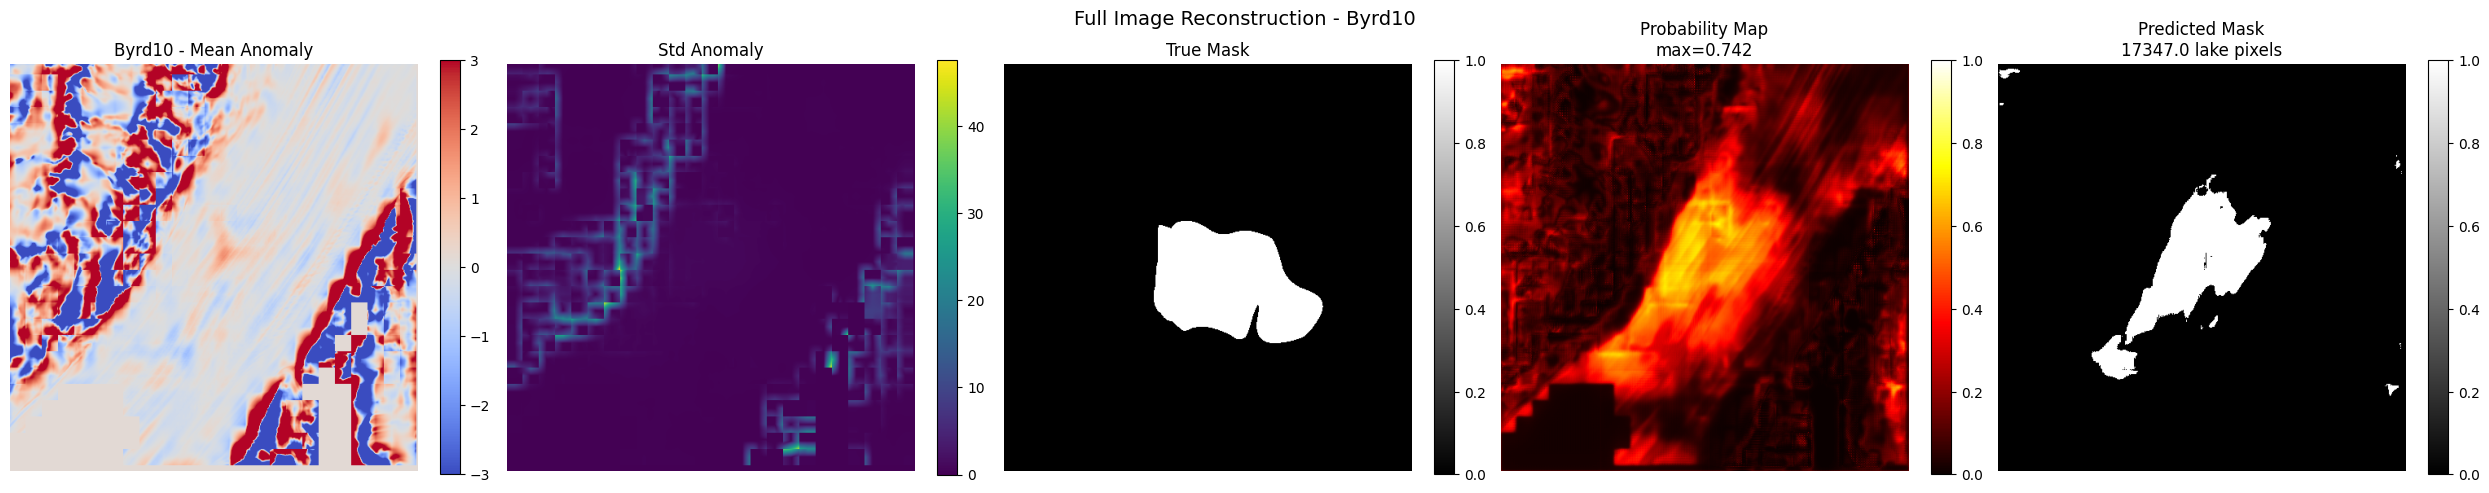

  Dice Score: 0.5443

--- Processing: CookEast134 ---
  Reconstructing 501x501 image with 3x3 patches...


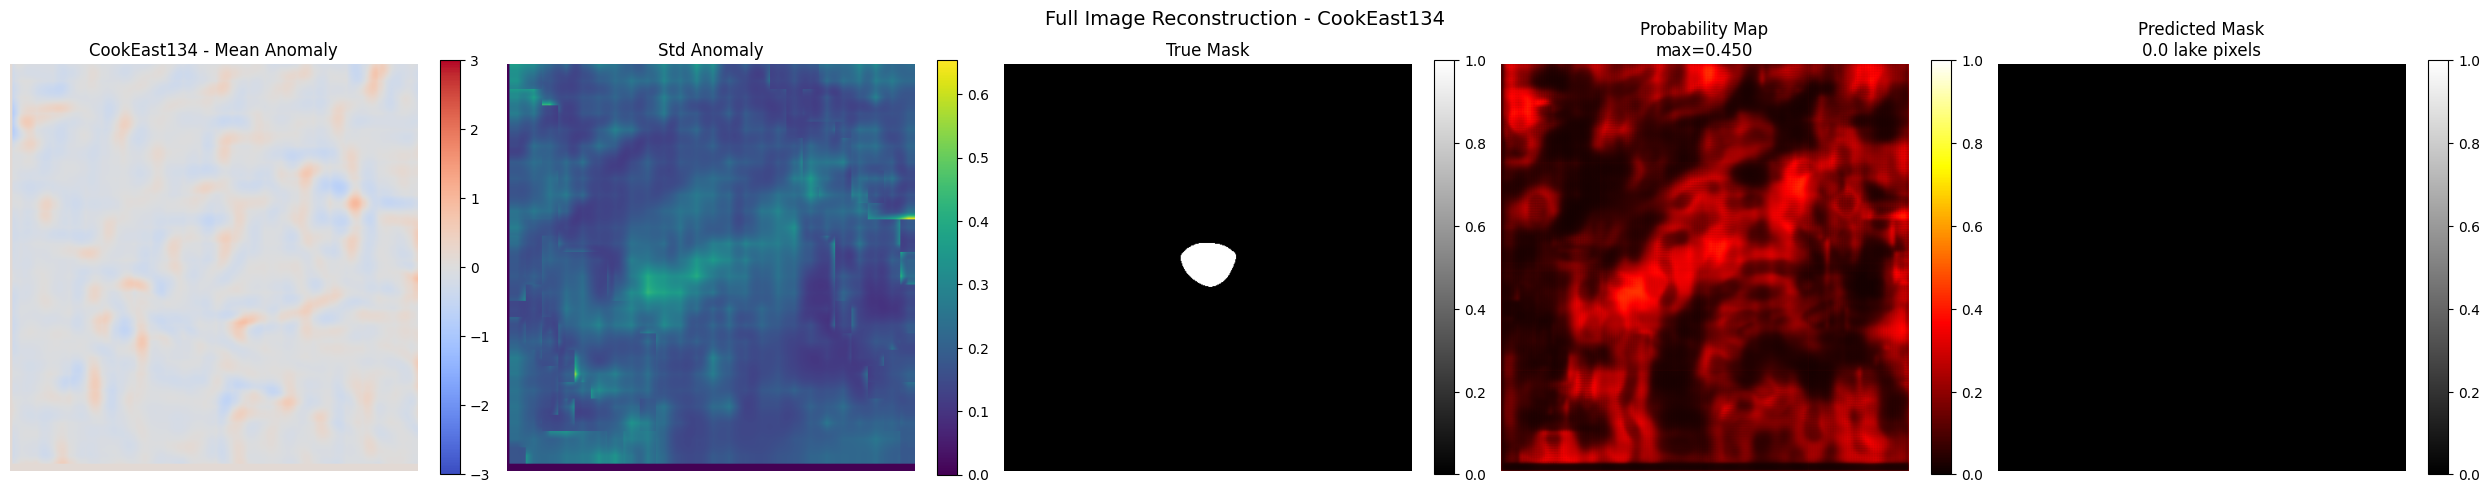

  Dice Score: 0.0000


In [10]:
# ============================================
# FULL IMAGE RECONSTRUCTION & PLOTTING 
# ============================================

def reconstruct_full_image(model, full_image_tensor, patch_size=256, stride=128, device='cuda', threshold=0.5):
    """
    Reconstruct full image with forced full coverage (no black bars)
    """
    model.eval()
    C, H, W = full_image_tensor.shape
    
    # Force dimensions to be covered by adjusting stride for last patch
    import math
    n_y = math.ceil((H - patch_size) / stride) + 1
    n_x = math.ceil((W - patch_size) / stride) + 1
    
    # Adjust stride for last patch to ensure coverage
    stride_y = stride
    stride_x = stride
    
    # Calculate actual step sizes to cover whole image
    if n_y > 1:
        stride_y = (H - patch_size) / (n_y - 1)
    if n_x > 1:
        stride_x = (W - patch_size) / (n_x - 1)
    
    # Initialize accumulators
    prob_accumulator = torch.zeros((H, W)).to(device)
    weight_accumulator = torch.zeros((H, W)).to(device)
    
    # Gaussian weights for smooth blending
    def get_gaussian_weights(patch_size):
        center = patch_size // 2
        y, x = torch.meshgrid(torch.arange(patch_size), torch.arange(patch_size), indexing='ij')
        gaussian = torch.exp(-((x - center)**2 + (y - center)**2) / (2 * (patch_size/4)**2))
        return gaussian / gaussian.max()
    
    gaussian_weights = get_gaussian_weights(patch_size).to(device)
    
    print(f"  Reconstructing {H}x{W} image with {n_y}x{n_x} patches...")
    
    with torch.no_grad():
        for i in range(n_y):
            for j in range(n_x):
                # Calculate patch position (ensures full coverage)
                y = min(int(i * stride_y), H - patch_size)
                x = min(int(j * stride_x), W - patch_size)
                
                patch = full_image_tensor[:, y:y+patch_size, x:x+patch_size].unsqueeze(0).to(device)
                logits = model(patch)
                probs = torch.sigmoid(logits).squeeze().cpu()
                
                weighted_probs = probs * gaussian_weights.cpu()
                
                prob_accumulator[y:y+patch_size, x:x+patch_size] += weighted_probs
                weight_accumulator[y:y+patch_size, x:x+patch_size] += gaussian_weights.cpu()
    
    weight_accumulator = torch.clamp(weight_accumulator, min=1e-8)
    averaged_probs = prob_accumulator / weight_accumulator
    full_pred = (averaged_probs > threshold).float()
    
    return full_pred.cpu(), averaged_probs.cpu()


def load_full_image(row, device='cuda'):
    """Load and preprocess a full image from dataframe row"""
    # Load tile
    tile_path = str(row["tile_path"])
    tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
    arr = tile_ds["anomaly"].values.astype(np.float32)
    tile_ds.close()
    
    # Process to 2-channel (mean, std)
    valid = np.isfinite(arr)
    valid_count = valid.sum(axis=0)
    
    arr_zeroed = np.where(valid, arr, 0.0)
    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
    
    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
    
    mean_img[valid_count == 0] = 0.0
    std_img[valid_count == 0] = 0.0
    
    x = np.stack([mean_img, std_img], axis=0)
    
    # Normalize
    GLOBAL_MEAN_MEAN = -2.4824232087901197 
    GLOBAL_STD_MEAN = 20.268677019954087   
    GLOBAL_STD_STD = 3.7701363263330427   
    
    x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
    x[1] = x[1] / GLOBAL_STD_STD
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Load true mask if exists
    if not pd.isna(row["mask_path"]):
        mask_path = str(row["mask_path"])
        mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
        true_mask = mask_ds["lake_mask"].values.astype(np.float32)
        mask_ds.close()
        true_mask = (true_mask > 0).astype(np.float32)
        true_mask = torch.tensor(true_mask)
        has_lake = True
    else:
        true_mask = None
        has_lake = False
    
    return torch.tensor(x, dtype=torch.float32), true_mask, row['name'], has_lake


def plot_full_image_results(model, val_df, num_samples=4, device='cuda', patch_size=256, stride=128, threshold=0.5):
    """
    Plot full image results with 5 panels, no black bars
    """
    print("\n" + "="*60)
    print("RECONSTRUCTING FULL VALIDATION IMAGES")
    print("="*60)
    
    # Select samples (mix of lake and null)
    lake_indices = []
    null_indices = []
    
    for idx in range(len(val_df)):
        if pd.isna(val_df.iloc[idx]["mask_path"]):
            null_indices.append(idx)
        else:
            lake_indices.append(idx)
    
    print(f"Found {len(lake_indices)} lake images, {len(null_indices)} null images")
    
    # Choose samples (at least one null if available)
    sample_indices = []
    if null_indices and len(sample_indices) < num_samples:
        sample_indices.append(null_indices[0])
        print(f"Adding null image: {val_df.iloc[null_indices[0]]['name']}")
    
    # Fill rest with lake images
    lake_samples = min(len(lake_indices), num_samples - len(sample_indices))
    if lake_samples > 0:
        sample_indices.extend(lake_indices[:lake_samples])
    
    # Reconstruct each image
    for idx in sample_indices:
        row = val_df.iloc[idx]
        print(f"\n--- Processing: {row['name']} ---")
        
        # Load full image
        full_image, true_mask, name, has_lake = load_full_image(row, device)
        
        # Reconstruct (no black bars)
        pred_mask, confidence = reconstruct_full_image(
            model, full_image, patch_size=patch_size, stride=stride, device=device, threshold=threshold
        )
        
        # Create 5-panel plot
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        
        # 1. Mean anomaly
        im0 = axes[0].imshow(full_image[0].cpu(), cmap='coolwarm', vmin=-3, vmax=3)
        axes[0].set_title(f'{name} - Mean Anomaly', fontsize=12)
        axes[0].axis('off')
        plt.colorbar(im0, ax=axes[0], fraction=0.046)
        
        # 2. Std anomaly
        im1 = axes[1].imshow(full_image[1].cpu(), cmap='viridis')
        axes[1].set_title('Std Anomaly', fontsize=12)
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], fraction=0.046)
        
        # 3. True mask (or null placeholder)
        if true_mask is not None:
            im2 = axes[2].imshow(true_mask.cpu(), cmap='gray', vmin=0, vmax=1)
            axes[2].set_title('True Mask', fontsize=12)
        else:
            blank = np.zeros((full_image.shape[1], full_image.shape[2]))
            im2 = axes[2].imshow(blank, cmap='gray', vmin=0, vmax=1)
            axes[2].set_title('NULL Image (No Lake)', fontsize=12)
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2], fraction=0.046)
        
        # 4. Probability map (no black bars!)
        im3 = axes[3].imshow(confidence.cpu(), cmap='hot', vmin=0, vmax=1)
        axes[3].set_title(f'Probability Map\nmax={confidence.max():.3f}', fontsize=12)
        axes[3].axis('off')
        plt.colorbar(im3, ax=axes[3], fraction=0.046)
        
        # 5. Predicted mask
        im4 = axes[4].imshow(pred_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        lake_pixels = pred_mask.sum().item()
        axes[4].set_title(f'Predicted Mask\n{lake_pixels} lake pixels', fontsize=12)
        axes[4].axis('off')
        plt.colorbar(im4, ax=axes[4], fraction=0.046)
        
        plt.suptitle(f'Full Image Reconstruction - {name}', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Calculate Dice if true mask exists
        if true_mask is not None:
            intersection = (pred_mask * true_mask).sum()
            union = pred_mask.sum() + true_mask.sum()
            dice = (2 * intersection + 1e-6) / (union + 1e-6)
            print(f"  Dice Score: {dice:.4f}")
        else:
            print(f"  Null image - checking for false positives...")
            if lake_pixels > 0:
                print(f"FALSE POSITIVE: Predicted {lake_pixels} lake pixels in null image")
            else:
                print(f"Correct: No lakes predicted in null image")


# ============================================
# RUN RECONSTRUCTION
# ============================================

plot_full_image_results(
    model=model,
    val_df=val_df,
    num_samples=4,
    device=device,
    patch_size=256,
    stride=128,
    threshold=0.5
)

  Reconstructing 501x501 image with 3x3 patches...


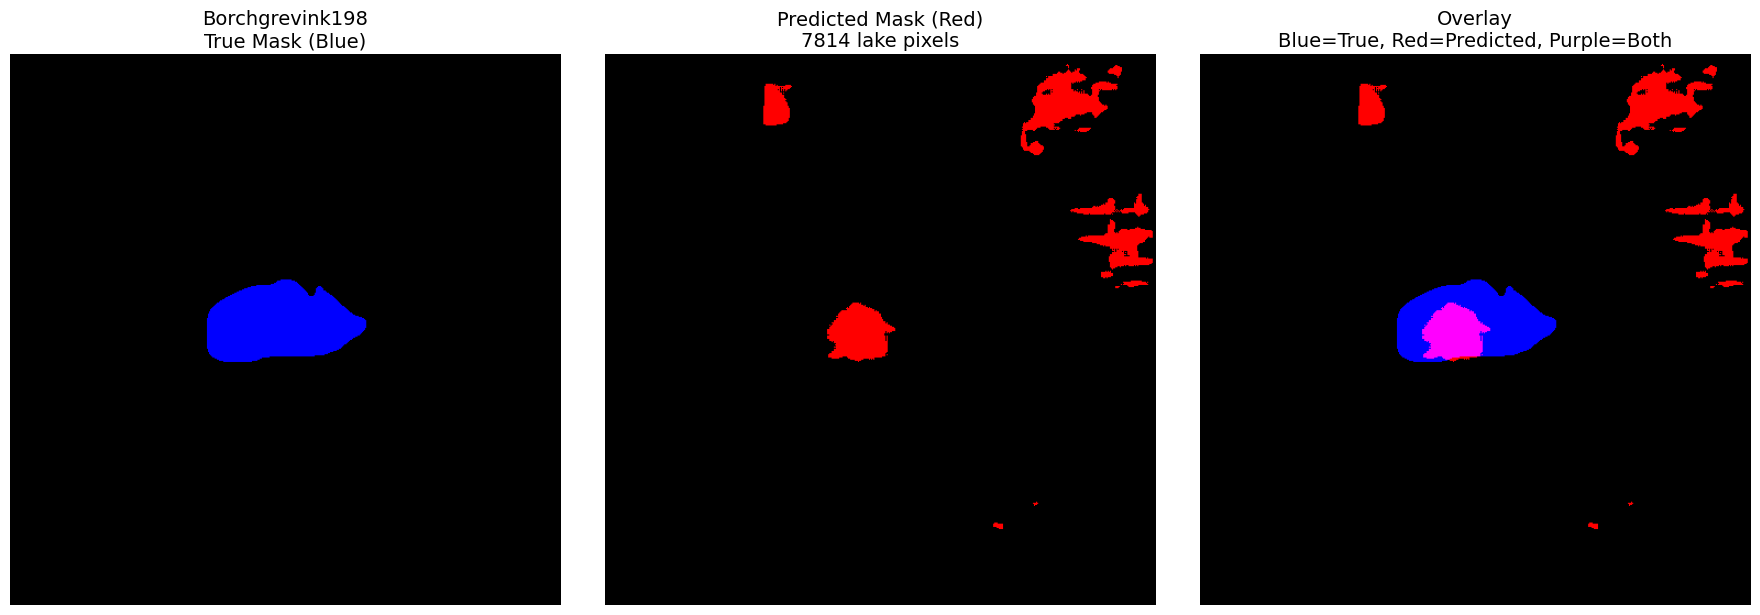

Dice Score: 0.2825
  Reconstructing 501x501 image with 3x3 patches...


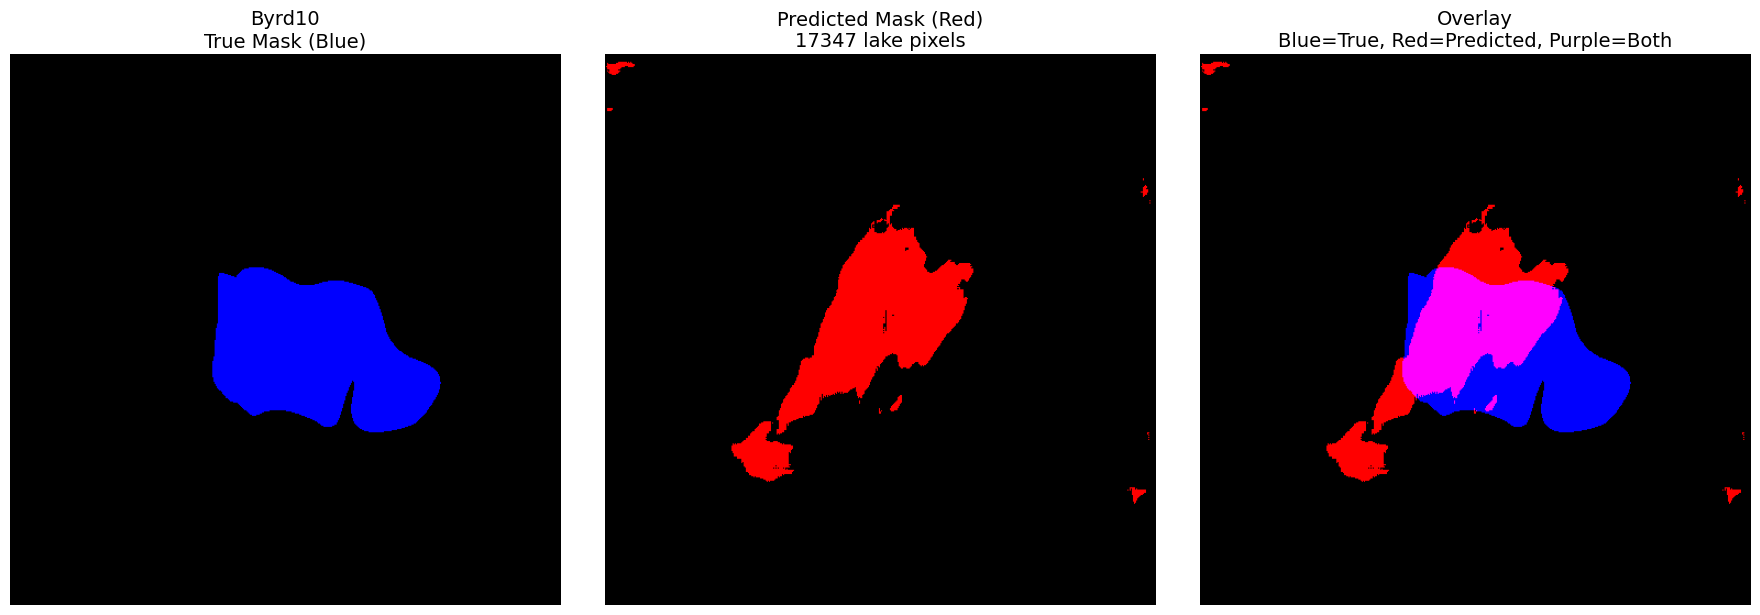

Dice Score: 0.5443
  Reconstructing 501x501 image with 3x3 patches...


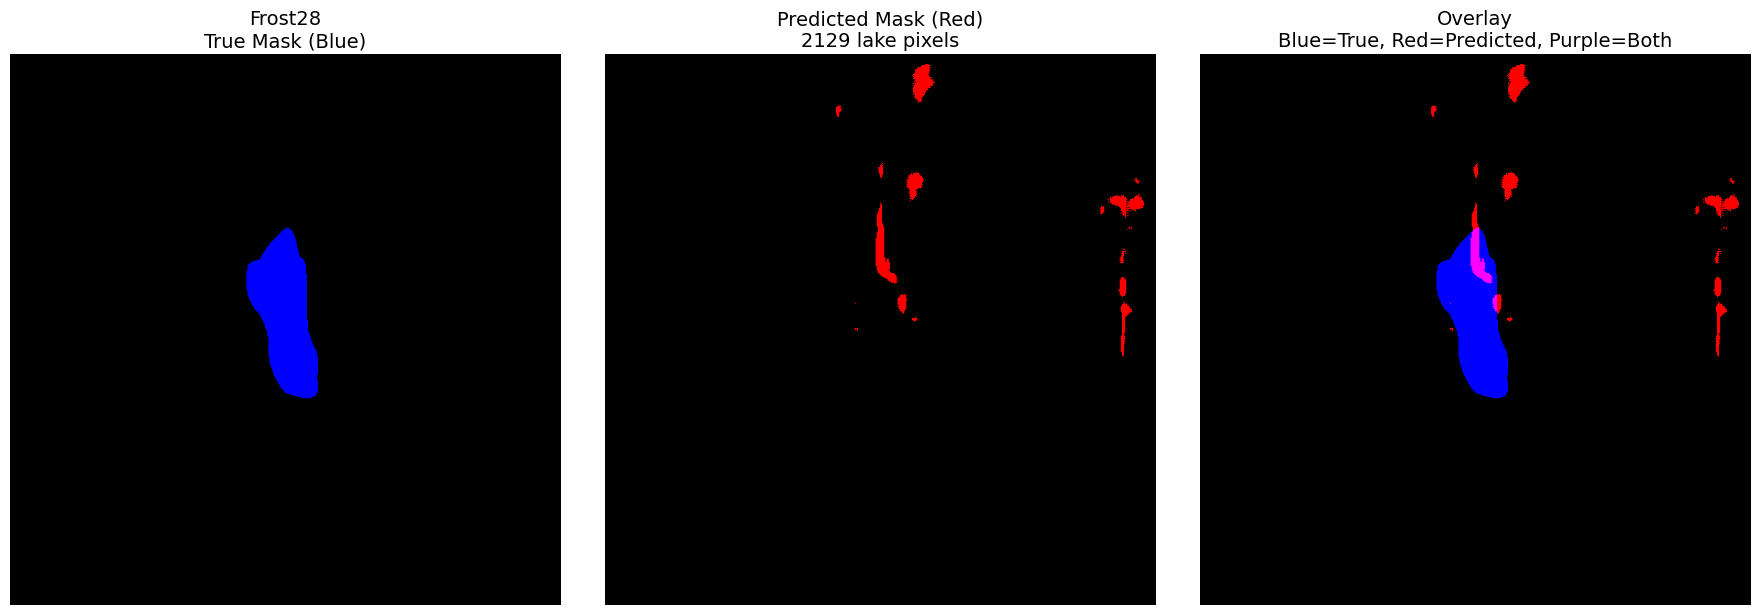

Dice Score: 0.1228
  Reconstructing 501x501 image with 3x3 patches...


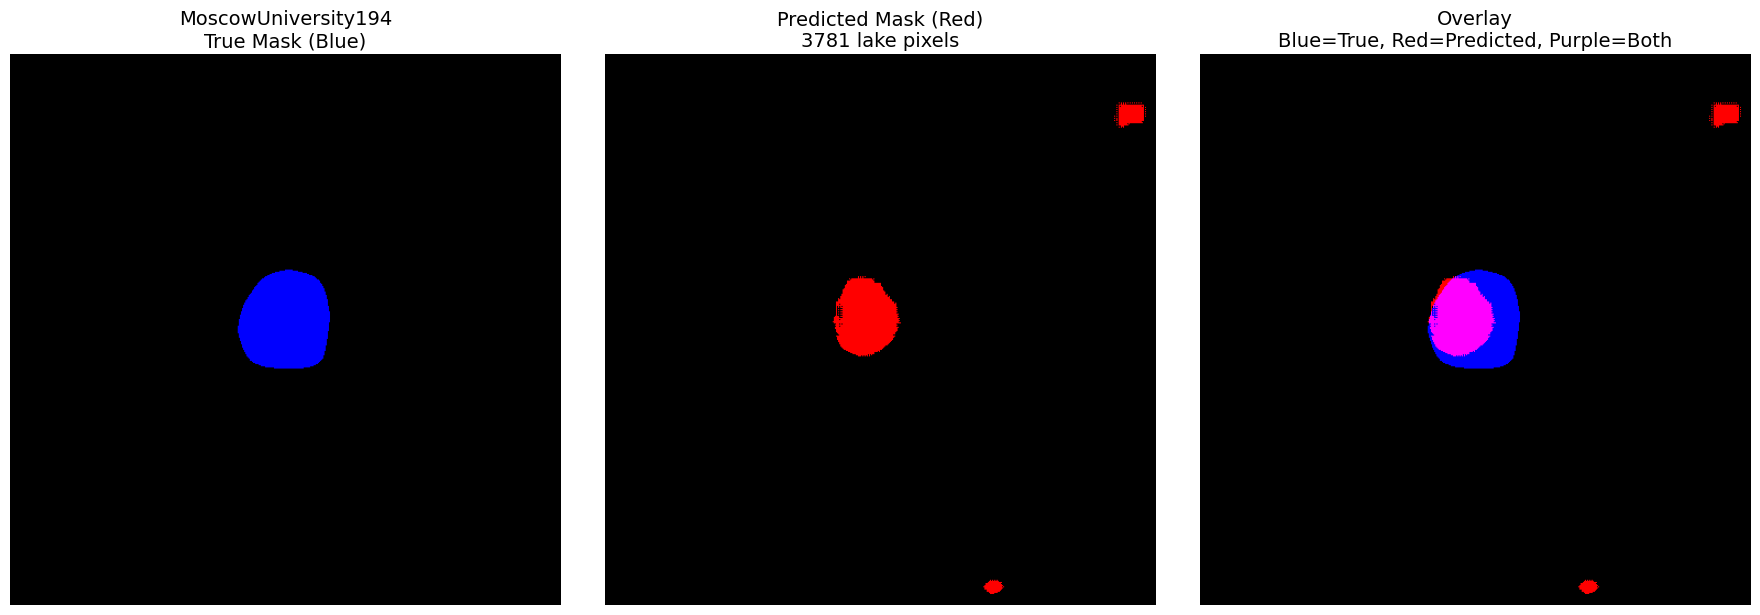

Dice Score: 0.6168


In [11]:
# ============================================
# PLOT IMAGE OVERLAY FOR FULL IMAGES
# ============================================

@torch.no_grad()
def plot_full_image_overlay(model, val_df, idx, device, patch_size=256, stride=128, threshold=0.5):
    """
    Simple overlay plot for full reconstructed images:
    Panel 1: True mask (blue)
    Panel 2: Predicted mask (red)
    Panel 3: Overlay (blue=true, red=predicted, purple=both)
    """
    model.eval()
    
    # Get the row
    row = val_df.iloc[idx]
    sample_name = row["name"]
    
    # Load full image
    full_image, true_mask, _, has_lake = load_full_image(row, device)
    
    # Reconstruct full prediction
    pred_mask, _ = reconstruct_full_image(
        model, full_image, patch_size=patch_size, stride=stride, device=device, threshold=threshold
    )
    
    # Convert to numpy
    true_np = true_mask.cpu().numpy() if true_mask is not None else None
    pred_np = pred_mask.cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Panel 1: True mask in blue
    if true_np is not None:
        # Create blue-only image
        blue_display = np.zeros((*true_np.shape, 3))
        blue_display[true_np > 0] = [0, 0, 1]  # Blue
        axes[0].imshow(blue_display)
        axes[0].set_title(f"{sample_name}\nTrue Mask (Blue)", fontsize=14)
    else:
        # Null image - show blank
        blank = np.zeros((full_image.shape[1], full_image.shape[2], 3))
        axes[0].imshow(blank)
        axes[0].set_title(f"{sample_name}\nNULL Image (No Lake)", fontsize=14)
    axes[0].axis("off")
    
    # Panel 2: Predicted mask in red
    red_display = np.zeros((*pred_np.shape, 3))
    red_display[pred_np > 0] = [1, 0, 0]  # Red
    axes[1].imshow(red_display)
    lake_pixels = pred_np.sum()
    axes[1].set_title(f"Predicted Mask (Red)\n{lake_pixels:.0f} lake pixels", fontsize=14)
    axes[1].axis("off")
    
    # Panel 3: Overlay
    if true_np is not None:
        overlay = np.zeros((*true_np.shape, 3))
        # True in blue
        overlay[true_np > 0] = [0, 0, 1]
        # Pred in red (adds to blue where both present)
        overlay[pred_np > 0] += [1, 0, 0]
        # Clip to [0,1] range
        overlay = np.clip(overlay, 0, 1)
        
        axes[2].imshow(overlay)
        axes[2].set_title("Overlay\nBlue=True, Red=Predicted, Purple=Both", fontsize=14)
    else:
        # For null images, just show red if false positives
        overlay = np.zeros((*pred_np.shape, 3))
        overlay[pred_np > 0] = [1, 0, 0]
        axes[2].imshow(overlay)
        if lake_pixels > 0:
            axes[2].set_title(f"FALSE POSITIVE\n{lake_pixels:.0f} pixels", fontsize=14)
        else:
            axes[2].set_title("Correct Null", fontsize=14)
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    if true_np is not None:
        intersection = (pred_np * true_np).sum()
        union = pred_np.sum() + true_np.sum()
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        print(f"Dice Score: {dice:.4f}")
    else:
        if lake_pixels > 0:
            print(f"False positive: {lake_pixels:.0f} lake pixels in null image")
        else:
            print(f"Null image correct")


# Plot examples (choose indices that include both lake and null)
for idx in [0, 1, 5, 10]:  # Adjust indices based on your data
    plot_full_image_overlay(
        model=model,
        val_df=val_df,
        idx=idx,
        device=device,
        patch_size=256,
        stride=128,
        threshold=0.5
    )


FINDING OPTIMAL THRESHOLD USING VALIDATION DATA


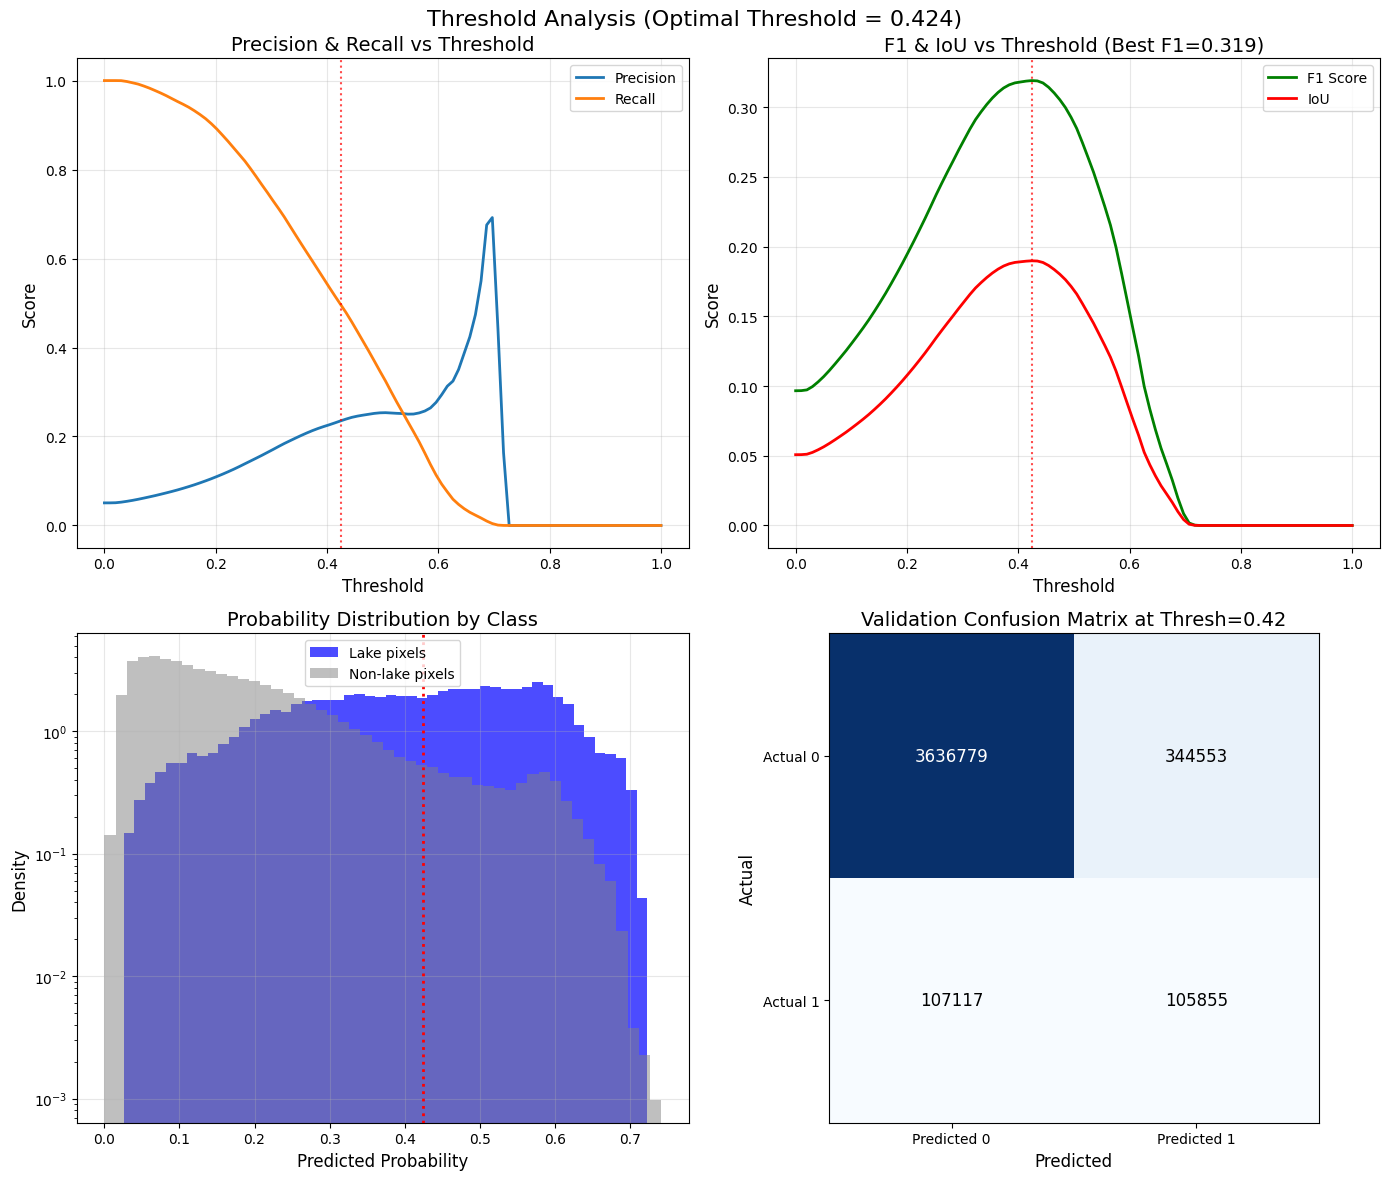


OPTIMAL THRESHOLD FOUND (FROM VALIDATION DATA)
Optimal threshold: 0.424
  F1 Score at optimal: 0.319
  IoU at optimal: 0.190
  Precision: 0.235
  Recall: 0.497
  Validation TP: 105855 | FP: 344553
  Validation FN: 107117 | TN: 3636779


In [12]:
# ============================================
# FIND OPTIMAL THRESHOLD USING VALIDATION DATA
# ============================================

def get_threshold_metrics(model, loader, device, n_thresholds=100):
    """
    Calculate metrics across thresholds for threshold analysis
    """
    model.eval()
    
    all_probs = []
    all_targets = []
    
    print("Collecting validation predictions for threshold analysis...")
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            
            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            targets = y.cpu().numpy().flatten()
            
            all_probs.extend(probs)
            all_targets.extend(targets)
    
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    
    # Calculate metrics for each threshold
    thresholds = np.linspace(0, 1, n_thresholds)
    precision = []
    recall = []
    f1_scores = []
    iou_scores = []
    
    for thresh in thresholds:
        preds = (all_probs > thresh).astype(float)
        
        tp = (preds * all_targets).sum()
        fp = (preds * (1 - all_targets)).sum()
        fn = ((1 - preds) * all_targets).sum()
        
        prec = tp / (tp + fp + 1e-6)
        rec = tp / (tp + fn + 1e-6)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-6)
        iou = tp / (tp + fp + fn + 1e-6)
        
        precision.append(prec)
        recall.append(rec)
        f1_scores.append(f1)
        iou_scores.append(iou)
    
    return thresholds, np.array(precision), np.array(recall), np.array(f1_scores), np.array(iou_scores), all_probs, all_targets


def plot_threshold_analysis_4panel(model, val_loader, device, n_thresholds=100):
    """
    Plot 4-panel threshold analysis figure and return optimal threshold
    """
    # Get metrics
    thresholds, precision, recall, f1_scores, iou_scores, all_probs, all_targets = get_threshold_metrics(
        model, val_loader, device, n_thresholds
    )
    
    # Find optimal threshold (max F1)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    # Create 4-panel figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Panel 1: Precision-Recall vs Threshold
    ax = axes[0, 0]
    ax.plot(thresholds, precision, label='Precision', linewidth=2)
    ax.plot(thresholds, recall, label='Recall', linewidth=2)
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Precision & Recall vs Threshold', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=optimal_threshold, color='red', linestyle=':', alpha=0.7)
    
    # Panel 2: F1 and IoU vs Threshold
    ax = axes[0, 1]
    ax.plot(thresholds, f1_scores, label='F1 Score', color='green', linewidth=2)
    ax.plot(thresholds, iou_scores, label='IoU', color='red', linewidth=2)
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'F1 & IoU vs Threshold (Best F1={f1_scores[optimal_idx]:.3f})', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=optimal_threshold, color='red', linestyle=':', alpha=0.7)
    
    # Panel 3: Probability Distribution
    ax = axes[1, 0]
    ax.hist(all_probs[all_targets==1], bins=50, alpha=0.7, label='Lake pixels', color='blue', density=True)
    ax.hist(all_probs[all_targets==0], bins=50, alpha=0.5, label='Non-lake pixels', color='gray', density=True)
    ax.axvline(x=optimal_threshold, color='red', linestyle=':', linewidth=2)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Probability Distribution by Class', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Panel 4: Confusion Matrix at Optimal Threshold (on validation)
    ax = axes[1, 1]
    preds_optimal = (all_probs > optimal_threshold).astype(float)
    tp = (preds_optimal * all_targets).sum()
    fp = (preds_optimal * (1 - all_targets)).sum()
    fn = ((1 - preds_optimal) * all_targets).sum()
    tn = ((1 - preds_optimal) * (1 - all_targets)).sum()
    
    cm = np.array([[tn, fp], [fn, tp]])
    
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
    ax.set_yticklabels(['Actual 0', 'Actual 1'])
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{int(cm[i, j])}', 
                          ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black",
                          fontsize=12)
    
    ax.set_title(f'Validation Confusion Matrix at Thresh={optimal_threshold:.2f}', fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    
    plt.suptitle(f'Threshold Analysis (Optimal Threshold = {optimal_threshold:.3f})', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("OPTIMAL THRESHOLD FOUND (FROM VALIDATION DATA)")
    print("="*60)
    print(f"Optimal threshold: {optimal_threshold:.3f}")
    print(f"  F1 Score at optimal: {f1_scores[optimal_idx]:.3f}")
    print(f"  IoU at optimal: {iou_scores[optimal_idx]:.3f}")
    print(f"  Precision: {precision[optimal_idx]:.3f}")
    print(f"  Recall: {recall[optimal_idx]:.3f}")
    print(f"  Validation TP: {int(tp)} | FP: {int(fp)}")
    print(f"  Validation FN: {int(fn)} | TN: {int(tn)}")
    
    return optimal_threshold


print("\n" + "="*60)
print("FINDING OPTIMAL THRESHOLD USING VALIDATION DATA")
print("="*60)

optimal_threshold = plot_threshold_analysis_4panel(
    model=model,
    val_loader=val_loader,
    device=device,
    n_thresholds=100
)


EVALUATING TEST SET WITH NORMALIZED MATRIX

Evaluating TEST data at threshold = 0.424...


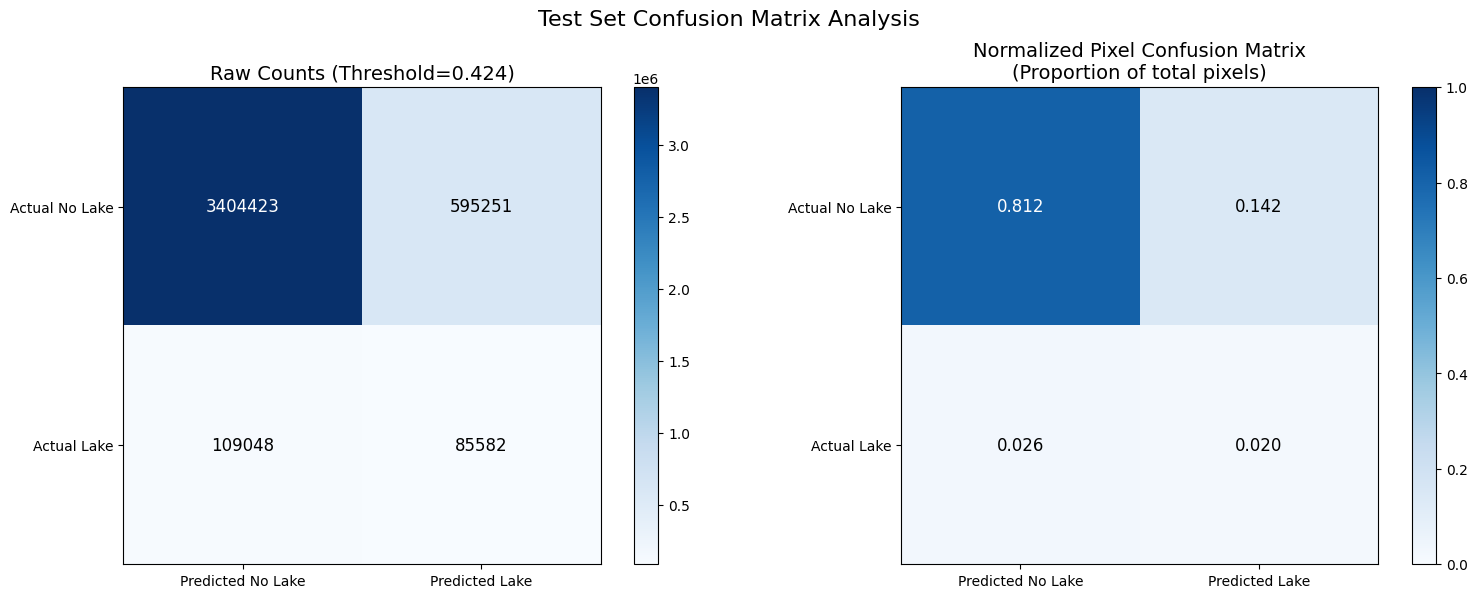


TEST SET RESULTS WITH NORMALIZED VALUES
Threshold used: 0.424

CONFUSION MATRIX (raw counts)
                Predicted No    Predicted Lake
Actual No Lake       3,404,423         595,251  ( 81.2% /  14.2% of total)
Actual Lake            109,048          85,582  (  2.6% /   2.0% of total)

CLASS-SPECIFIC METRICS
LAKE CLASS (Positive) - 194,630 pixels (4.64% of data)
  Precision: 0.1257  (of predicted lakes, 12.6% are correct)
  Recall:    0.4397    (of actual lakes, 44.0% were found)
  F1 Score:  0.1955
  False Negatives: 109,048 (56.0% of lakes missed)

BACKGROUND CLASS (Negative) - 3,999,674 pixels (95.36% of data)
  Precision: 0.9690  (of predicted background, 96.9% are correct)
  Recall:    0.8512    (of actual background, 85.1% were correct)
  F1 Score:  0.9063
  False Positives: 595,251 (14.88% of background mistaken as lakes)

OVERALL METRICS
Accuracy:           0.8321 (83.21%)
Balanced Accuracy:  0.6454
IoU (Jaccard Index): 0.1083
F1 Score (lake):    0.1955


In [ ]:
# ============================================
# TEST SET CONFUSION MATRIX WITH NORMALIZED VALUES
# ============================================

@torch.no_grad()
def test_confusion_matrix_normalized(model, test_loader, device, threshold):
    """
    Generate confusion matrix with normalized values (0-1) for imbalanced data
    """
    model.eval()
    
    all_preds = []
    all_targets = []
    
    print(f"\nEvaluating TEST data at threshold = {threshold:.3f}...")
    
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device)
            
            logits = model(X)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(y.cpu().numpy().flatten())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    
    # Calculate percentages
    p_tn = 100 * tn / total
    p_fp = 100 * fp / total
    p_fn = 100 * fn / total
    p_tp = 100 * tp / total
    
    # Class-specific metrics
    # For lake class (positive)
    lake_total = tp + fn
    lake_precision = tp / (tp + fp + 1e-6)
    lake_recall = tp / (lake_total + 1e-6)
    lake_f1 = 2 * (lake_precision * lake_recall) / (lake_precision + lake_recall + 1e-6)
    
    # For background class (negative)
    bg_total = tn + fp
    bg_precision = tn / (tn + fn + 1e-6)
    bg_recall = tn / (bg_total + 1e-6)
    bg_f1 = 2 * (bg_precision * bg_recall) / (bg_precision + bg_recall + 1e-6)
    
    # Overall metrics
    accuracy = (tp + tn) / total
    balanced_accuracy = (lake_recall + bg_recall) / 2
    iou = tp / (tp + fp + fn + 1e-6)
    
    # Plot with normalized values (blue color scheme)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Raw counts (blue)
    ax = axes[0]
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted No Lake', 'Predicted Lake'])
    ax.set_yticklabels(['Actual No Lake', 'Actual Lake'])
    ax.set_title(f'Raw Counts (Threshold={threshold:.3f})', fontsize=14)
    
    # Add text with raw counts
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{int(cm[i, j])}', 
                          ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black",
                          fontsize=12)
    plt.colorbar(im, ax=ax)
    
    # Plot 2: Normalized Pixel Confusion Matrix (blue, decimals)
    ax = axes[1]
    
    # Normalize confidence matrix based on row sums
    row_sums = cm.sum(axis=1)
    cm_normalized = cm.astype('float') / row_sums[:, np.newaxis]
    
    im = ax.imshow(cm_normalized, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted No Lake', 'Predicted Lake'])
    ax.set_yticklabels(['Actual No Lake', 'Actual Lake'])
    ax.set_title('Normalized Pixel Confusion Matrix\n(Proportion of total pixels)', fontsize=14)
    
    # Add text with normalized values (3 decimal places)
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{cm_normalized[i, j]:.3f}', 
                          ha="center", va="center", 
                          color="white" if cm_normalized[i, j] > 0.5 else "black",
                          fontsize=12)
    plt.colorbar(im, ax=ax)
    
    plt.suptitle(f'Test Set Confusion Matrix Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive results
    print("\n" + "="*70)
    print("TEST SET RESULTS WITH NORMALIZED VALUES")
    print("="*70)
    print(f"Threshold used: {threshold:.3f}")
    print(f"\n{'='*40}")
    print("CONFUSION MATRIX (raw counts)")
    print(f"{'='*40}")
    print(f"                Predicted No    Predicted Lake")
    print(f"Actual No Lake    {tn:12,d}    {fp:12,d}  ({p_tn:5.1f}% / {p_fp:5.1f}% of total)")
    print(f"Actual Lake       {fn:12,d}    {tp:12,d}  ({p_fn:5.1f}% / {p_tp:5.1f}% of total)")
    
    print(f"\n{'='*40}")
    print("CLASS-SPECIFIC METRICS")
    print(f"{'='*40}")
    print(f"LAKE CLASS (Positive) - {lake_total:,d} pixels ({100*lake_total/total:.2f}% of data)")
    print(f"  Precision: {lake_precision:.4f}  (of predicted lakes, {lake_precision*100:.1f}% are correct)")
    print(f"  Recall:    {lake_recall:.4f}    (of actual lakes, {lake_recall*100:.1f}% were found)")
    print(f"  F1 Score:  {lake_f1:.4f}")
    print(f"  False Negatives: {fn:,d} ({100*fn/lake_total:.1f}% of lakes missed)")
    
    print(f"\nBACKGROUND CLASS (Negative) - {bg_total:,d} pixels ({100*bg_total/total:.2f}% of data)")
    print(f"  Precision: {bg_precision:.4f}  (of predicted background, {bg_precision*100:.1f}% are correct)")
    print(f"  Recall:    {bg_recall:.4f}    (of actual background, {bg_recall*100:.1f}% were correct)")
    print(f"  F1 Score:  {bg_f1:.4f}")
    print(f"  False Positives: {fp:,d} ({100*fp/bg_total:.2f}% of background mistaken as lakes)")
    
    print(f"\n{'='*40}")
    print("OVERALL METRICS")
    print(f"{'='*40}")
    print(f"Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Balanced Accuracy:  {balanced_accuracy:.4f}")
    print(f"IoU (Jaccard Index): {iou:.4f}")
    print(f"F1 Score (lake):    {lake_f1:.4f}")
    
    return {
        'cm': cm,
        'cm_normalized': cm_normalized,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'lake_precision': lake_precision, 'lake_recall': lake_recall, 'lake_f1': lake_f1,
        'bg_precision': bg_precision, 'bg_recall': bg_recall, 'bg_f1': bg_f1,
        'accuracy': accuracy, 'balanced_accuracy': balanced_accuracy, 'iou': iou
    }


print("\n" + "="*60)
print("EVALUATING TEST SET WITH NORMALIZED MATRIX")
print("="*60)

test_results = test_confusion_matrix_normalized(
    model=model,
    test_loader=test_loader,
    device=device,
    threshold=optimal_threshold 
)